In [1]:
!bash -lc 'module load Miniforge3/24.1.2-0 && source $EBROOTMINIFORGE3/bin/activate && conda activate hycom-cice'
import xarray as xr

The following modules were not unloaded:
  (Use "module --force purge" to unload all):

  1) StdEnv


In [2]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from matplotlib.colors import TwoSlopeNorm

def ArcticMap():

    fig, ax = plt.subplots(
        figsize=(8, 8),
        subplot_kw={"projection": ccrs.NorthPolarStereo(central_longitude=0.0)},
    )

    ax.set_extent([-180, 180, 48, 90], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor=cfeature.COLORS["land"], edgecolor="grey", zorder=2)
    ax.add_feature(cfeature.COASTLINE.with_scale("50m"), edgecolor="grey", linewidth=0.4, zorder=3)
    ax.gridlines()
      
    return fig, ax
    
def pcolormesh_curvilinear(lon, lat, data, ax=None, **kwargs):

    proj = ax.projection
    pxy = proj.transform_points(ccrs.PlateCarree(), lon, lat)
    px, py = pxy[:, :, 0], pxy[:, :, 1]
    invalid = ~np.isfinite(px) | ~np.isfinite(py)
    px = np.where(invalid, 0.0, px)
    py = np.where(invalid, 0.0, py)
    data = np.where(invalid, np.nan, data)
    return ax.pcolormesh(px, py, data, **kwargs)


In [3]:
from glob import glob
import cftime

varlist = ["uvellvl","vvellvl","ubaro","vbaro"]

NORCPM_PATH = "/cluster/projects/nn9481k/arnaud/Script-tools/SEACLIM/norcpm_clim/"
#REFRUN_PATH = "/cluster/projects/nn9481k/arnaud/Script-tools/SEACLIM/ref_clim/"
REFRUN_PATH = "/cluster/work/users/arnelt/clim_ave/"
REFRUN_PATH_BARO = "/cluster/projects/nn9481k/arnaud/Script-tools/SEACLIM/ref_clim/"

#filelist_norcpm = sorted(glob(NORCPM_PATH + "noresm2-mm-seaclim_hindcast.blom.hmphy20n.clim.1993-2024.startmonth11.leadmonth1-64.mem1-10.nc"))
filelist_norcpm = sorted(glob(NORCPM_PATH + "noresm2-mm-seaclim_hindcast.blom*"))
filelist_refrun = sorted(glob(REFRUN_PATH + "clim_1993_2024_*"))
filelist_refrun_baro = sorted(glob(REFRUN_PATH_BARO + "clim_1993_2024_*"))

common_time = [
    cftime.DatetimeNoLeap(1999, m, 15)
    for m in range(11, 13)
] + [
    cftime.DatetimeNoLeap(y, m, 15)
    for y in range(2000,2005)
    for m in range(1, 13)
] + [
    cftime.DatetimeNoLeap(2005, m, 15)
    for m in range(1, 3)
]

norcpm_datasets = []

for f in filelist_norcpm:
    ds_temp = xr.open_dataset(f, use_cftime=True)

    if "depth_bnds" in ds_temp.variables:
        ds_temp = ds_temp.drop_vars("depth_bnds")
    if ds_temp.attrs.get("bounds") is not None:
        ds_temp["depth"].attrs.pop("bounds")

    # Replace the existing time coordinate
    ds_temp = ds_temp.assign_coords(time=common_time)

    norcpm_datasets.append(ds_temp)

ds_norcpm = xr.merge(norcpm_datasets)
ds_temp.close()

ds_norcpm = ds_norcpm.drop_vars(["plon", "plat"])
ds_norcpm = ds_norcpm[varlist]

ds_refrun_temp = xr.open_mfdataset(filelist_refrun, combine="by_coords", use_cftime=True, chunks={"time": 1})
ds_refrun_baro = xr.open_mfdataset(filelist_refrun_baro, combine="by_coords", use_cftime=True, chunks={"time": 1})
ds_refrun_baro = ds_refrun_baro.assign_coords(time=ds_refrun_temp.time)
ds_refrun = xr.merge([ds_refrun_temp, ds_refrun_baro])
ds_refrun = ds_refrun.assign_coords(
    lon=ds_refrun_temp.longitude,
    lat=ds_refrun_temp.latitude
)
ds_refrun["lon"] = ds_refrun.lon.isel(time=0)
ds_refrun["lat"] = ds_refrun.lat.isel(time=0)

ds_refrun = xr.concat([ds_refrun] * 7, dim="time")
ds_refrun = ds_refrun.isel(time=slice(10, 74))

ds_refrun = ds_refrun.assign_coords(time=common_time)

rename_dict = {
    "uo":"uvellvl",
    "vo":"vvellvl",
    "so":"salnlvl"
}
ds_refrun = ds_refrun.rename(rename_dict)

"""lon2d = ds_refrun.longitude.isel(time=0).drop_vars("time")
lat2d = ds_refrun.latitude.isel(time=0).drop_vars("time")

ds_refrun = (
    ds_refrun
    .drop_vars(["longitude", "latitude"])
    .assign_coords(
        lon=((lon2d + 360) % 360),
        lat=lat2d
    )
)"""

ds_refrun = ds_refrun[varlist + ["salnlvl"]]

/tmp/ipykernel_2703492/1695559179.py:31: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds_temp = xr.open_dataset(f, use_cftime=True)
/cluster/projects/nn9481k/conda/arnelt/hycom-cice/lib/python3.11/site-packages/xarray/coding/times.py:383: CFWarning: this date/calendar/year zero convention is not supported by CF
  cftime.num2date(num_dates, units, calendar, only_use_cftime_datetimes=True)
/tmp/ipykernel_2703492/1695559179.py:31: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds_temp = xr.op

In [4]:
from abfile.abfile import ABFileGrid

grid = ABFileGrid("/cluster/home/arnelt/NERSC-HYCOM-CICE/TP2a0.10/topo/regional.grid", "r")

pang = grid.read_field("pang")

In [5]:
pang

masked_array(
  data=[[ 0.66820025,  0.66659176,  0.6649728 , ..., -0.5756515 ,
         -0.57782483, -0.57998514],
        [ 0.670658  ,  0.6690497 ,  0.6674308 , ..., -0.5780452 ,
         -0.5802214 , -0.5823846 ],
        [ 0.6731262 ,  0.67151815,  0.66989946, ..., -0.58045197,
         -0.582631  , -0.58479697],
        ...,
        [ 2.0934284 ,  2.0960965 ,  2.098777  , ..., -2.2395425 ,
         -2.2361622 , -2.232799  ],
        [ 2.0963743 ,  2.0990458 ,  2.1017296 , ..., -2.2425983 ,
         -2.2392173 , -2.2358534 ],
        [ 2.0993075 ,  2.1019824 ,  2.1046698 , ..., -2.2456367 ,
         -2.2422552 , -2.238891  ]],
  mask=False,
  fill_value=np.float64(1e+20),
  dtype='>f4')

REFRUN


<Figure size 640x480 with 0 Axes>

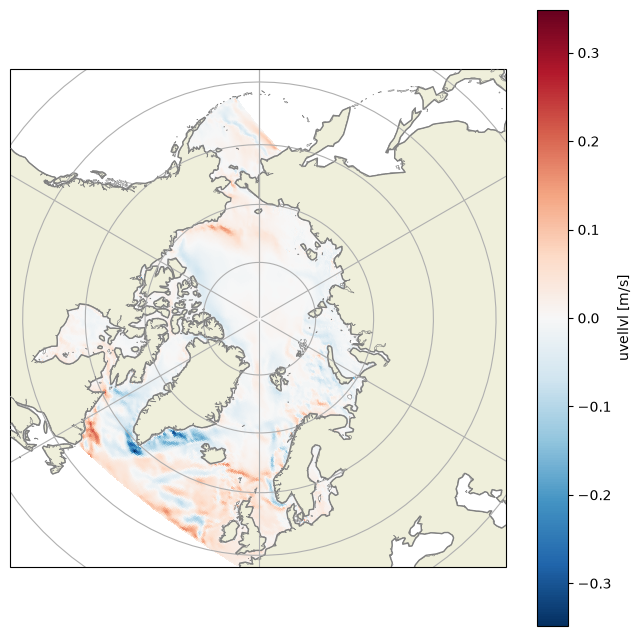

<Figure size 640x480 with 0 Axes>

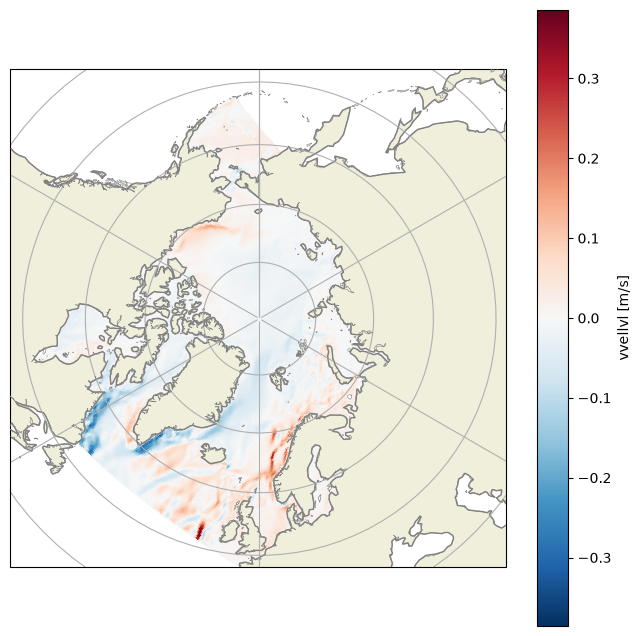

<Figure size 640x480 with 0 Axes>

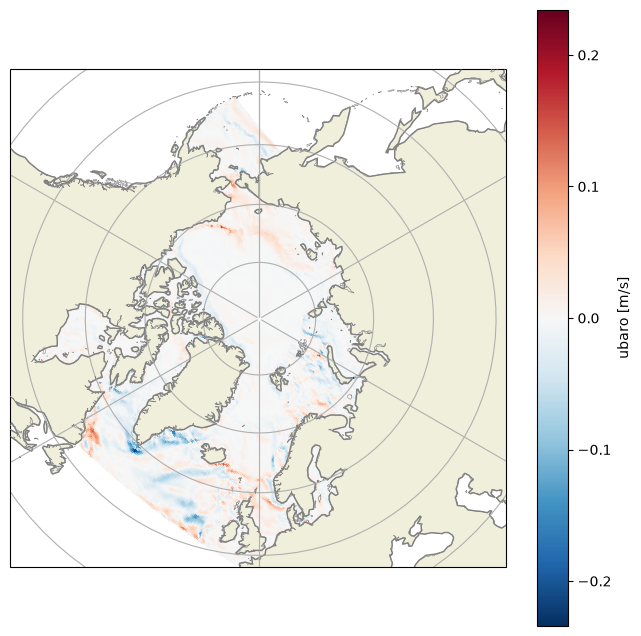

<Figure size 640x480 with 0 Axes>

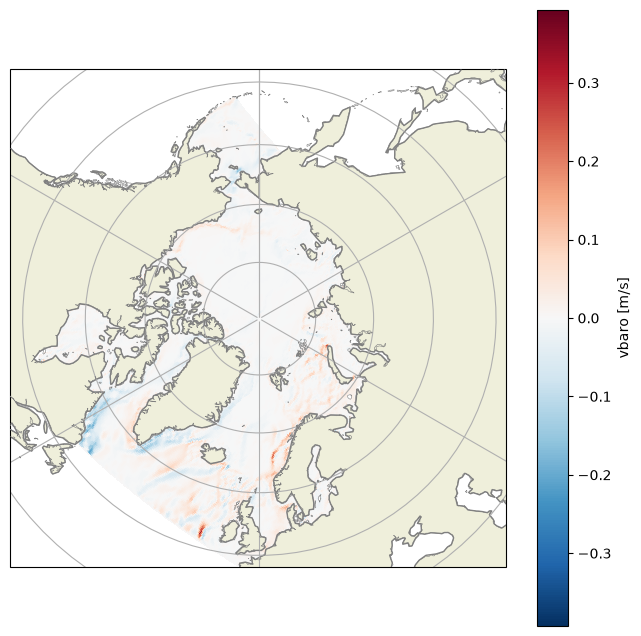

NORCPM


<Figure size 640x480 with 0 Axes>

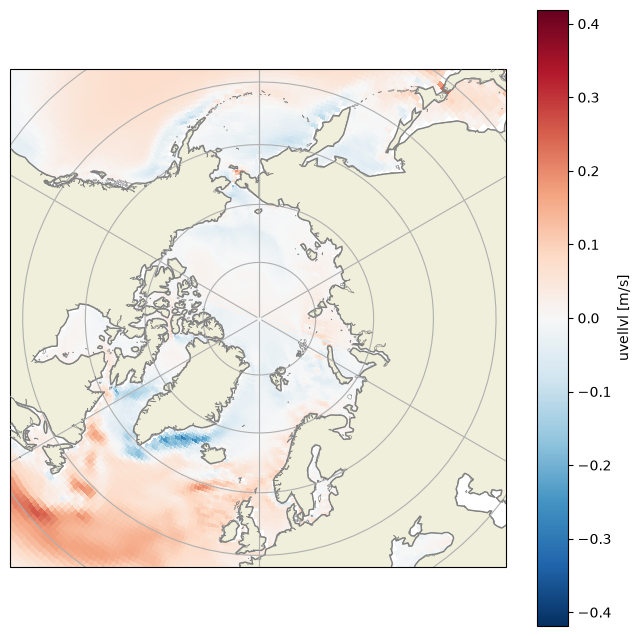

<Figure size 640x480 with 0 Axes>

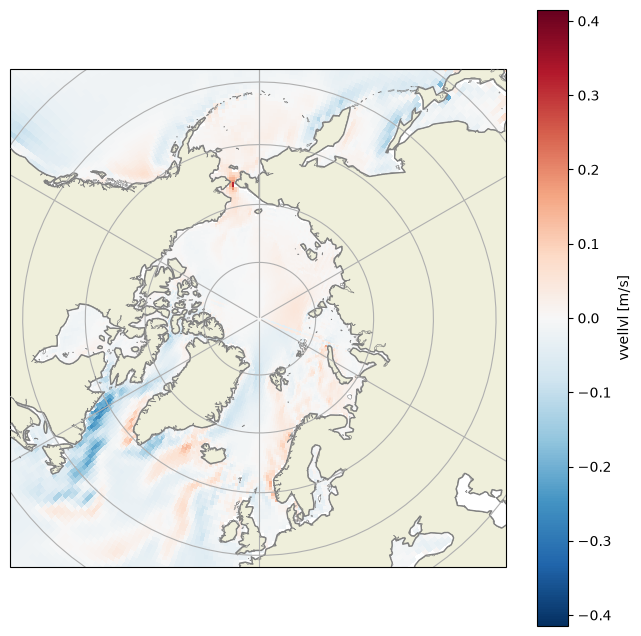

<Figure size 640x480 with 0 Axes>

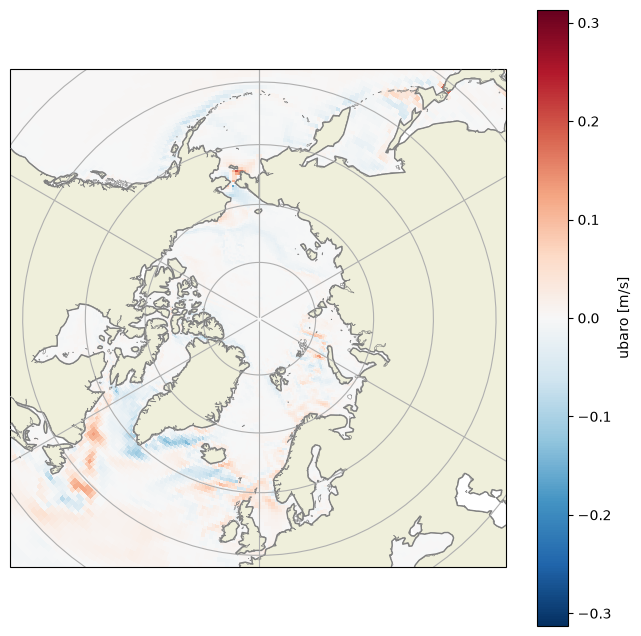

<Figure size 640x480 with 0 Axes>

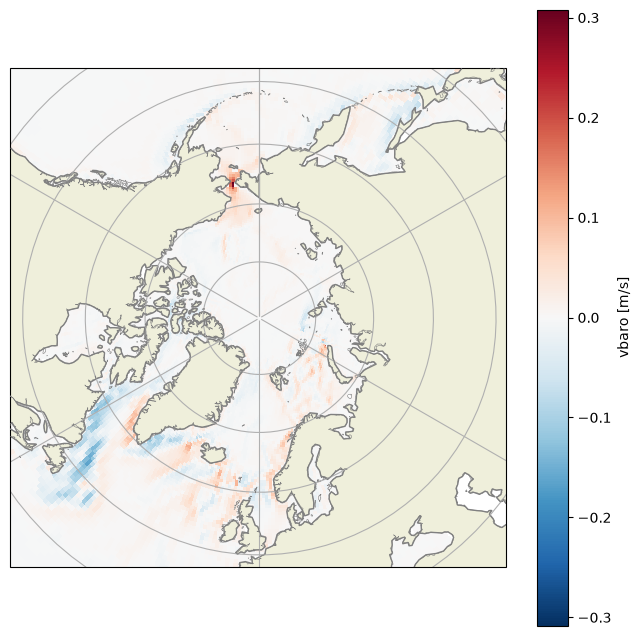

In [6]:
print("REFRUN")
for (i,var) in enumerate(varlist):
    if var == "ubaro" or var == "vbaro":
        temp = ds_refrun[var].mean(dim="time")
    else:
        temp = ds_refrun[var].isel(depth=0).mean(dim="time")
    plt.figure(i)
    fig, ax = ArcticMap()
    vmax = np.nanmax(np.abs(temp.values))
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    p = pcolormesh_curvilinear(temp.lon.values, temp.lat.values, temp.values, ax=ax, cmap="RdBu_r", norm=norm)
    fig.colorbar(p, ax=ax, label=f"{var} [m/s]")
    plt.show()

print("NORCPM")
for (i,var) in enumerate(varlist):
    if var == "ubaro" or var == "vbaro":
        temp = ds_norcpm[var].mean(dim="time")
    else:
        temp = ds_norcpm[var].isel(depth=0).mean(dim="time")
    plt.figure(i+10)
    fig, ax = ArcticMap()
    vmax = np.nanmax(np.abs(temp.values))
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    p = pcolormesh_curvilinear(temp.lon.values, temp.lat.values, temp.values, ax=ax, cmap="RdBu_r", norm=norm)
    fig.colorbar(p, ax=ax, label=f"{var} [m/s]")
    plt.show()

In [7]:
ds_refrun["speed"] = (ds_refrun["uvellvl"]**2 + ds_refrun["vvellvl"]**2) ** (1/2)
ds_norcpm["speed"] = (ds_norcpm["uvellvl"]**2 + ds_norcpm["vvellvl"]**2) ** (1/2)
varlist += ["speed"]

<Figure size 640x480 with 0 Axes>

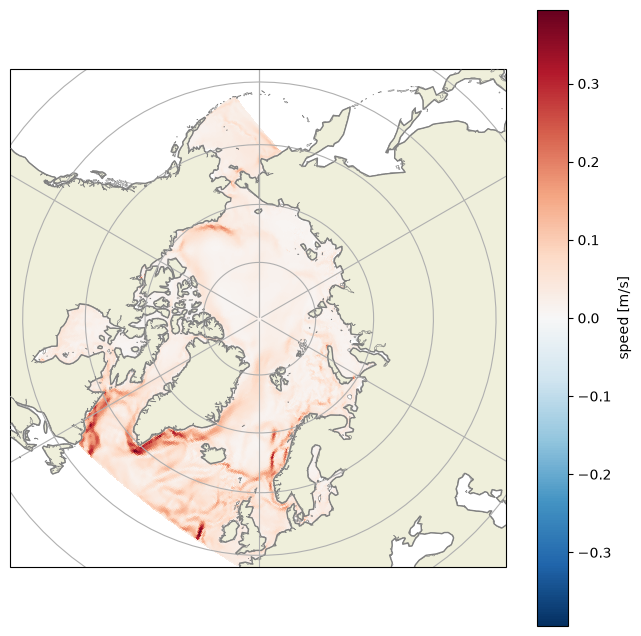

<Figure size 640x480 with 0 Axes>

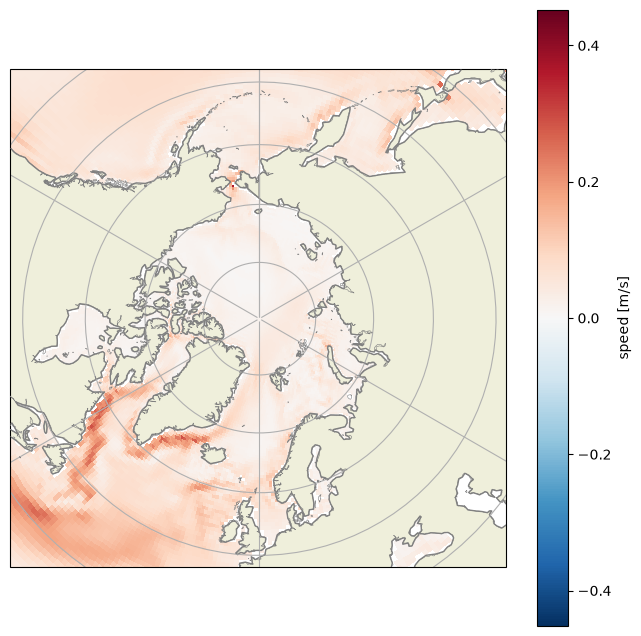

In [8]:
plt.figure(1)
temp = ds_refrun["speed"].isel(depth=0).mean(dim="time")
fig, ax = ArcticMap()
vmax = np.nanmax(np.abs(temp.values))
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
p = pcolormesh_curvilinear(temp.lon.values, temp.lat.values, temp.values, ax=ax, cmap="RdBu_r", norm=norm)
fig.colorbar(p, ax=ax, label="speed [m/s]")
plt.show()

plt.figure(2)
temp = ds_norcpm["speed"].isel(depth=0).mean(dim="time")
fig, ax = ArcticMap()
vmax = np.nanmax(np.abs(temp.values))
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
p = pcolormesh_curvilinear(temp.lon.values, temp.lat.values, temp.values, ax=ax, cmap="RdBu_r", norm=norm)
fig.colorbar(p, ax=ax, label="speed [m/s]")
plt.show()

In [9]:
theta = pang
ds_refrun["uvellvl"], ds_refrun["vvellvl"] = (ds_refrun["uvellvl"]*np.cos(theta) - ds_refrun["vvellvl"]*np.sin(theta),
                                              ds_refrun["uvellvl"]*np.sin(theta) + ds_refrun["vvellvl"]*np.cos(theta))
ds_refrun["ubaro"], ds_refrun["vbaro"] = (ds_refrun["ubaro"]*np.cos(theta) - ds_refrun["vbaro"]*np.sin(theta),
                                          ds_refrun["ubaro"]*np.sin(theta) + ds_refrun["vbaro"]*np.cos(theta))

In [10]:
import xesmf as xe

regridder = xe.Regridder(
    ds_refrun,
    ds_norcpm,
    method="bilinear",
    periodic=False
)

ds_refrun_interp = regridder(ds_refrun).compute()
ds_refrun.close()

/cluster/projects/nn9481k/conda/arnelt/hycom-cice/lib/python3.11/site-packages/xarray/computation/apply_ufunc.py:452: PerformanceWarning: Regridding is increasing the number of chunks by a factor of 6.0, you might want to specify sizes in `output_chunks` in the regridder call. Default behaviour is to preserve the chunk sizes from the input (190, 200).
  result_vars[name] = func(*variable_args)
/cluster/projects/nn9481k/conda/arnelt/hycom-cice/lib/python3.11/site-packages/xarray/computation/apply_ufunc.py:452: PerformanceWarning: Regridding is increasing the number of chunks by a factor of 6.0, you might want to specify sizes in `output_chunks` in the regridder call. Default behaviour is to preserve the chunk sizes from the input (190, 200).
  result_vars[name] = func(*variable_args)
/cluster/projects/nn9481k/conda/arnelt/hycom-cice/lib/python3.11/site-packages/xarray/computation/apply_ufunc.py:452: PerformanceWarning: Regridding is increasing the number of chunks by a factor of 6.0, yo

In [11]:
ds_baro = ds_refrun_interp[["ubaro","vbaro"]]

ds_refrun_interp_depth = ds_refrun_interp.drop_vars(["ubaro","vbaro"]).interp(
    depth=ds_norcpm.depth,
    method="linear"
)

ds_refrun_interp = xr.merge([ds_refrun_interp_depth, ds_baro])

ds_refrun_interp_depth.close()
ds_baro.close()

/tmp/ipykernel_2703492/3926519354.py:8: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_refrun_interp = xr.merge([ds_refrun_interp_depth, ds_baro])
/tmp/ipykernel_2703492/3926519354.py:8: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_refrun_interp = xr.merge([ds_refrun_interp_depth, ds_baro])


In [12]:
"""theta2 = norcpm_grid["angle"]
ds_refrun_interp["uvellvl"], ds_refrun_interp["vvellvl"] = (ds_refrun_interp["uvellvl"]*np.cos(theta2) + ds_refrun_interp["vvellvl"]*np.sin(theta2),
                                                            -ds_refrun_interp["uvellvl"]*np.sin(theta2) + ds_refrun_interp["vvellvl"]*np.cos(theta2))
ds_refrun_interp["ubaro"], ds_refrun_interp["vbaro"] = (ds_refrun_interp["ubaro"]*np.cos(theta2) + ds_refrun_interp["vbaro"]*np.sin(theta2),
                                                        -ds_refrun_interp["ubaro"]*np.sin(theta2) + ds_refrun_interp["vbaro"]*np.cos(theta2))"""

'theta2 = norcpm_grid["angle"]\nds_refrun_interp["uvellvl"], ds_refrun_interp["vvellvl"] = (ds_refrun_interp["uvellvl"]*np.cos(theta2) + ds_refrun_interp["vvellvl"]*np.sin(theta2),\n                                                            -ds_refrun_interp["uvellvl"]*np.sin(theta2) + ds_refrun_interp["vvellvl"]*np.cos(theta2))\nds_refrun_interp["ubaro"], ds_refrun_interp["vbaro"] = (ds_refrun_interp["ubaro"]*np.cos(theta2) + ds_refrun_interp["vbaro"]*np.sin(theta2),\n                                                        -ds_refrun_interp["ubaro"]*np.sin(theta2) + ds_refrun_interp["vbaro"]*np.cos(theta2))'

REFRUN


<Figure size 640x480 with 0 Axes>

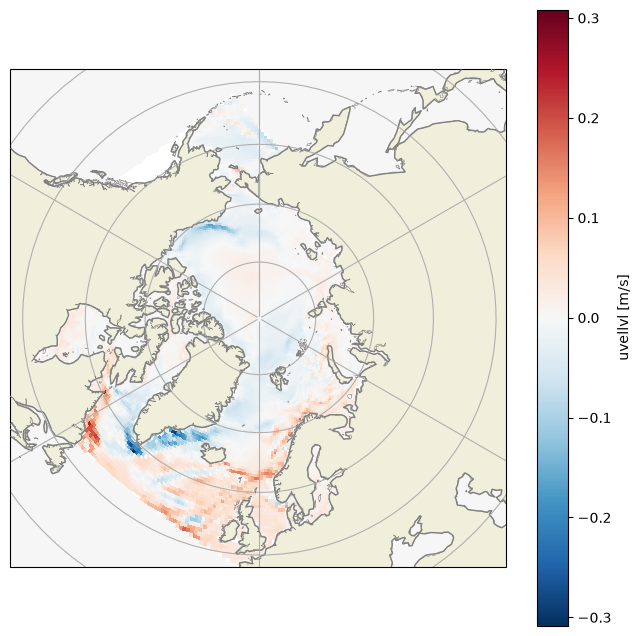

<Figure size 640x480 with 0 Axes>

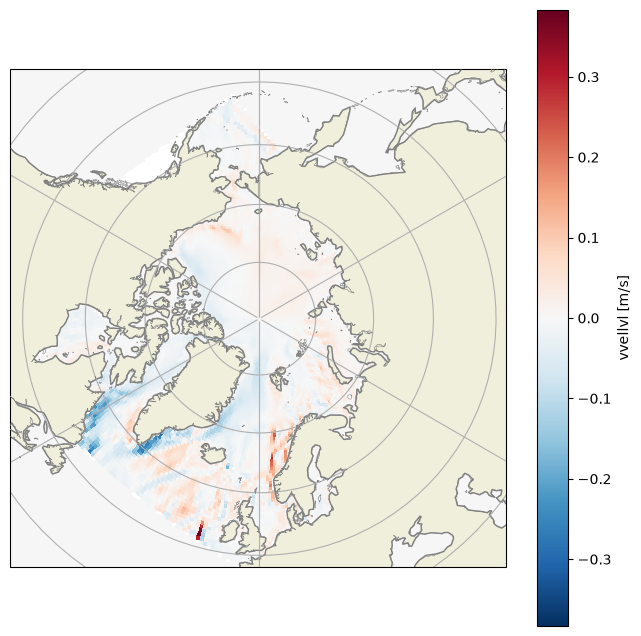

<Figure size 640x480 with 0 Axes>

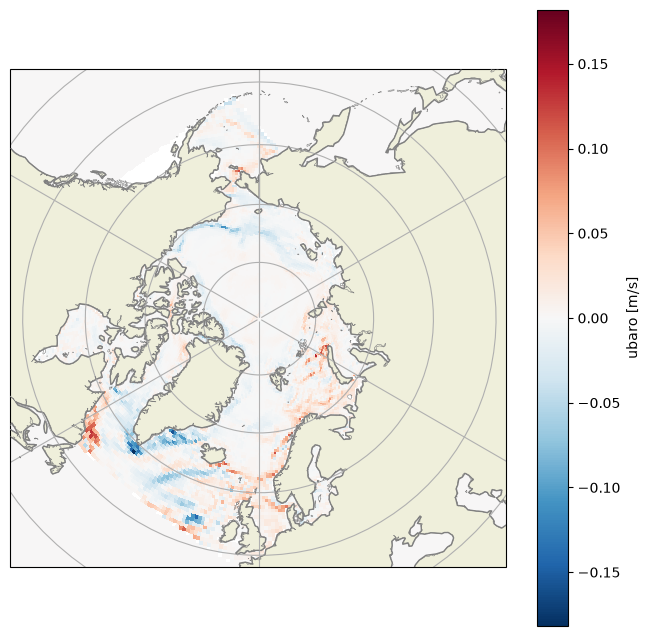

<Figure size 640x480 with 0 Axes>

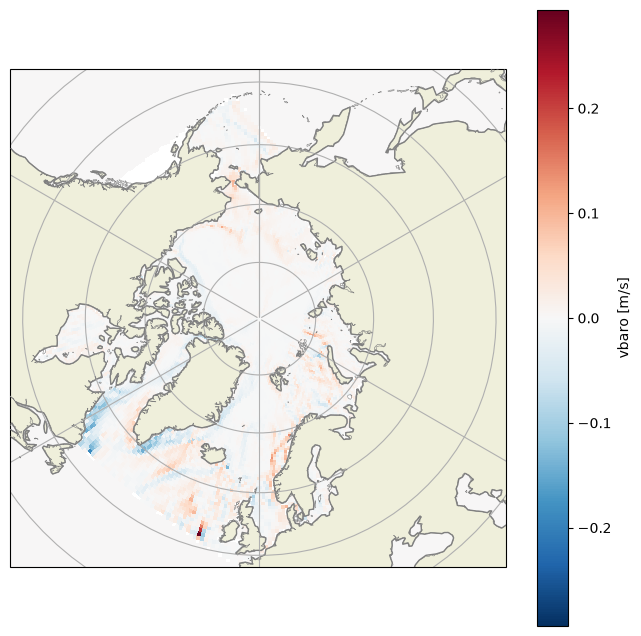

<Figure size 640x480 with 0 Axes>

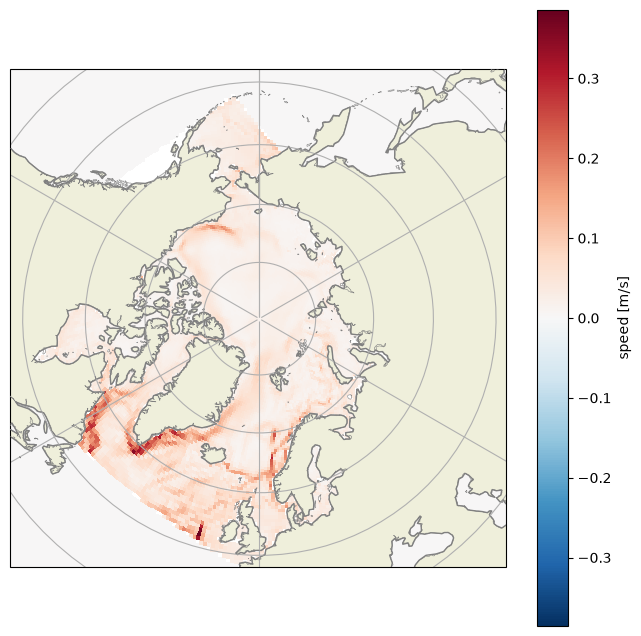

In [13]:
print("REFRUN")
for (i,var) in enumerate(varlist):
    if var == "ubaro" or var == "vbaro":
        temp = ds_refrun_interp[var].mean(dim="time")
    else:
        temp = ds_refrun_interp[var].isel(depth=0).mean(dim="time")
    plt.figure(i)
    fig, ax = ArcticMap()
    vmax = np.nanmax(np.abs(temp.values))
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    p = pcolormesh_curvilinear(temp.lon.values, temp.lat.values, temp.values, ax=ax, cmap="RdBu_r", norm=norm)
    fig.colorbar(p, ax=ax, label=f"{var} [m/s]")
    plt.show()

In [14]:
ds_bias = ds_norcpm - ds_refrun_interp

In [15]:
ds_bias

<xarray.Dataset> Size: 15GB
Dimensions:  (depth: 70, time: 64, y: 385, x: 360)
Coordinates:
  * depth    (depth) float64 560B 0.0 5.0 10.0 ... 6.25e+03 6.5e+03 6.75e+03
  * time     (time) object 512B 1999-11-15 00:00:00 ... 2005-02-15 00:00:00
    lon      (y, x) float64 1MB 250.5 251.5 252.5 253.5 ... 250.1 250.1 250.0
    lat      (y, x) float64 1MB -80.11 -80.11 -80.11 ... 62.59 62.35 62.12
Dimensions without coordinates: y, x
Data variables:
    uvellvl  (time, depth, y, x) float64 5GB nan nan nan nan ... nan nan nan nan
    vvellvl  (time, depth, y, x) float64 5GB nan nan nan nan ... nan nan nan nan
    ubaro    (time, y, x) float64 71MB nan nan nan nan nan ... nan nan nan nan
    vbaro    (time, y, x) float64 71MB nan nan nan nan nan ... nan nan nan nan
    speed    (time, depth, y, x) float64 5GB nan nan nan nan ... nan nan nan nan
Attributes:
    CDI:                        Climate Data Interface version 2.0.6 (https:/...
    Conventions:                CF-1.6
    history:                    Tue Jul 07 11:45:26 2026: cdo -s -O setreftim...
    NCO:                        netCDF Operators version 5.1.3 (Homepage = ht...
    history_of_appended_files:  Tue Jul  7 11:03:55 2026: Appended file norcp...
    CDO:                        Climate Data Operators version 2.0.6 (https:/...
    regrid_method:              bilinear

In [16]:
ds_bias = ds_bias.where(ds_refrun_interp.salnlvl > 20, 0)
ds_bias["ubaro"] = ds_bias["ubaro"].isel(depth=0, drop=True)
ds_bias["vbaro"] = ds_bias["vbaro"].isel(depth=0, drop=True)

<Figure size 640x480 with 0 Axes>

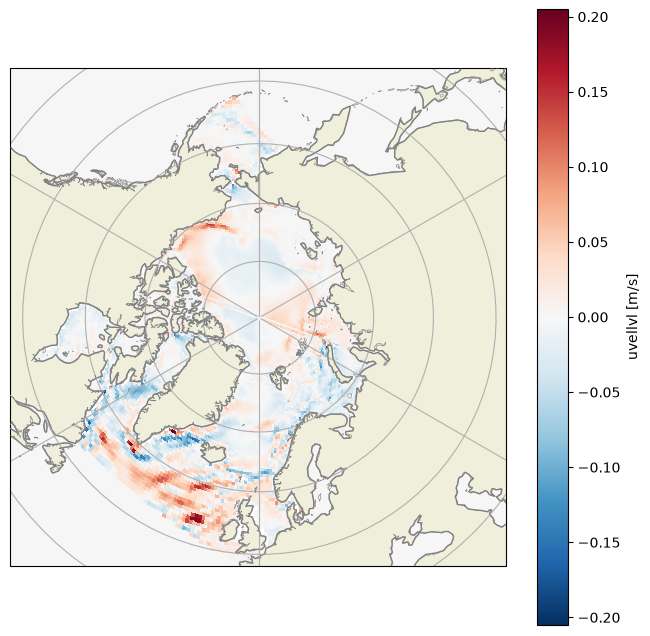

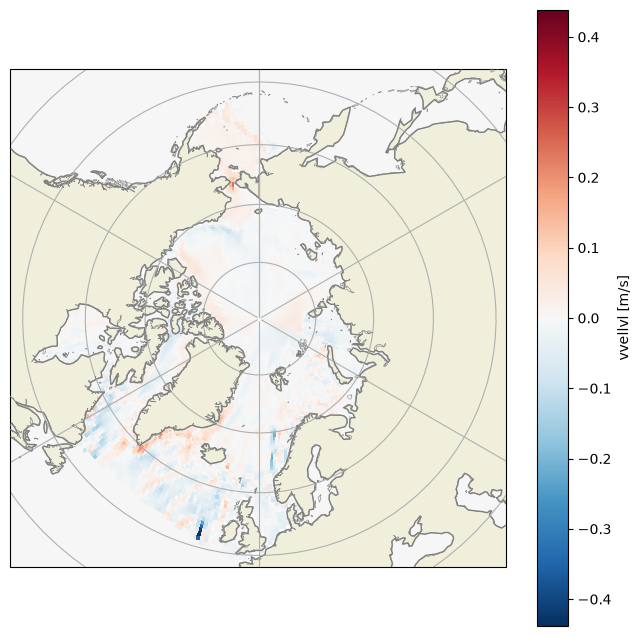

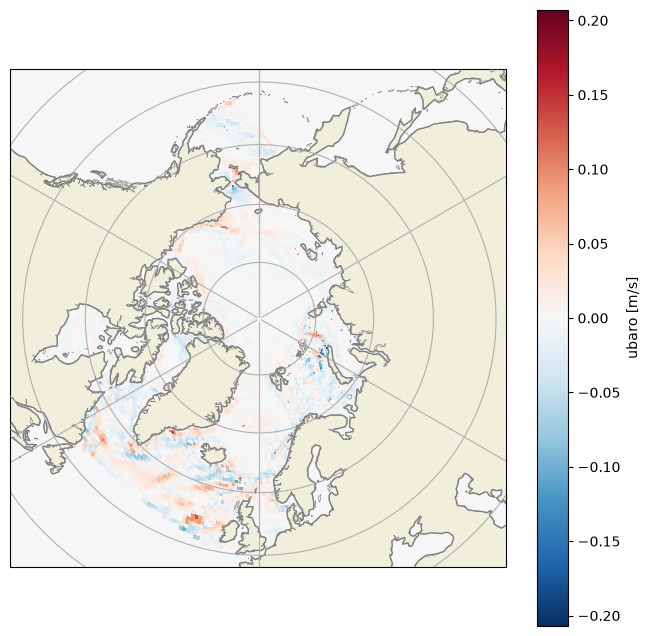

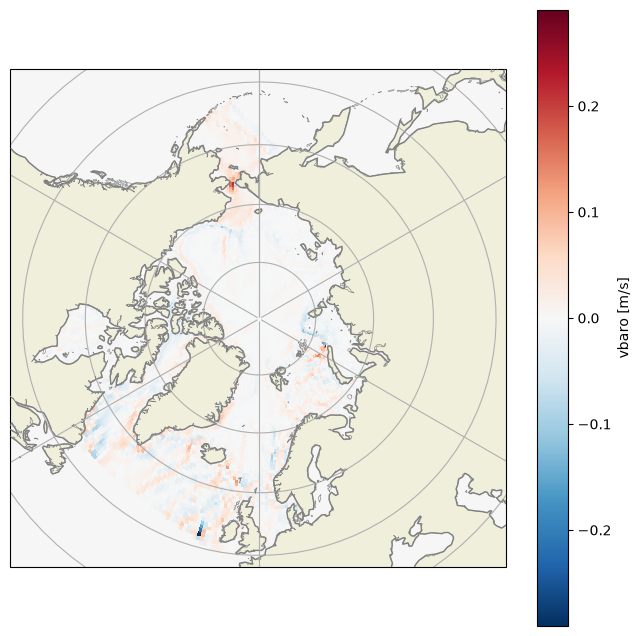

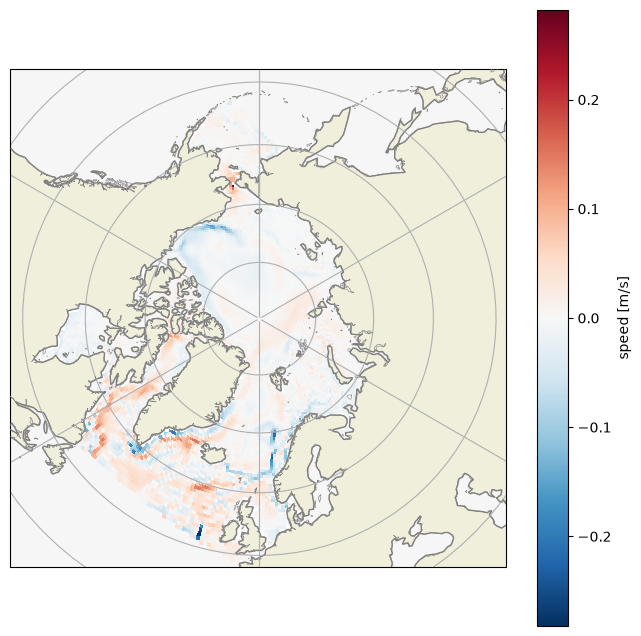

In [17]:
for (i,var) in enumerate(varlist):
    if var == "ubaro" or var == "vbaro":
        temp = ds_bias[var].mean(dim="time")
    else:
        temp = ds_bias[var].isel(depth=0).mean(dim="time")
    plt.figure(i)
    fig, ax = ArcticMap()
    vmax = np.nanmax(np.abs(temp.values))
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    p = pcolormesh_curvilinear(temp.lon.values, temp.lat.values, temp.values, ax=ax, cmap="RdBu_r", norm=norm)
    fig.colorbar(p, ax=ax, label=f"{var} [m/s]")

Atlantic West   : j= 301, i=  60, grid=(55.22°, 310.03°)
Atlantic East   : j= 298, i=  89, grid=(54.00°, 339.49°)
Pacific         : j= 306, i= 291, grid=(58.17°, 182.17°)


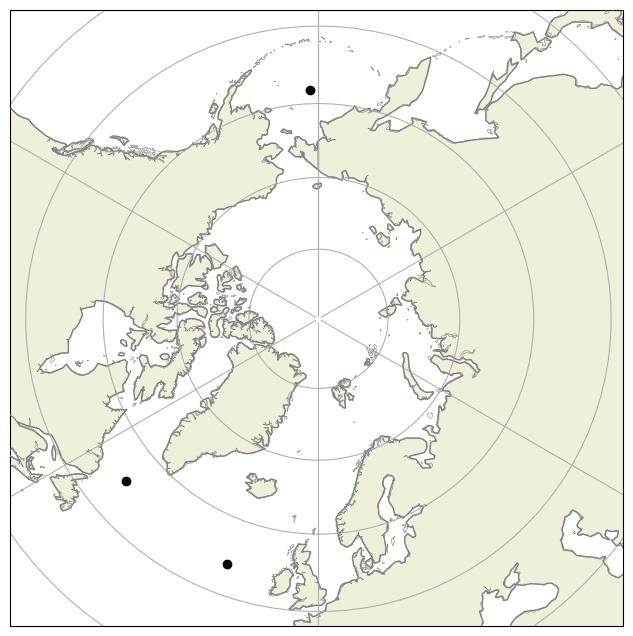

In [18]:
POINTS = {
    "Atlantic West": {"lat": 55.0, "lon": -50.0},
    "Atlantic East": {"lat": 54.0, "lon": -20.0},
    "Pacific": {"lat": 58.0, "lon": -178.0},
}

lon = ds_norcpm["lon"].values   # shape (j,i)
lat = ds_norcpm["lat"].values    # shape (j,i)

point_idx = {}
fig, ax = ArcticMap()

for name, p in POINTS.items():
    dist2 = (lon - (p["lon"]%360))**2 + (lat - p["lat"])**2
    j, i = np.unravel_index(np.nanargmin(dist2), dist2.shape)

    point_idx[name] = (j, i)

    print(
        f"{name:16s}: j={j:4d}, i={i:4d}, "
        f"grid=({lat[j,i]:.2f}°, {lon[j,i]:.2f}°)"
    )
    plt.plot(lon[j,i],lat[j,i],"ko",transform=ccrs.PlateCarree())

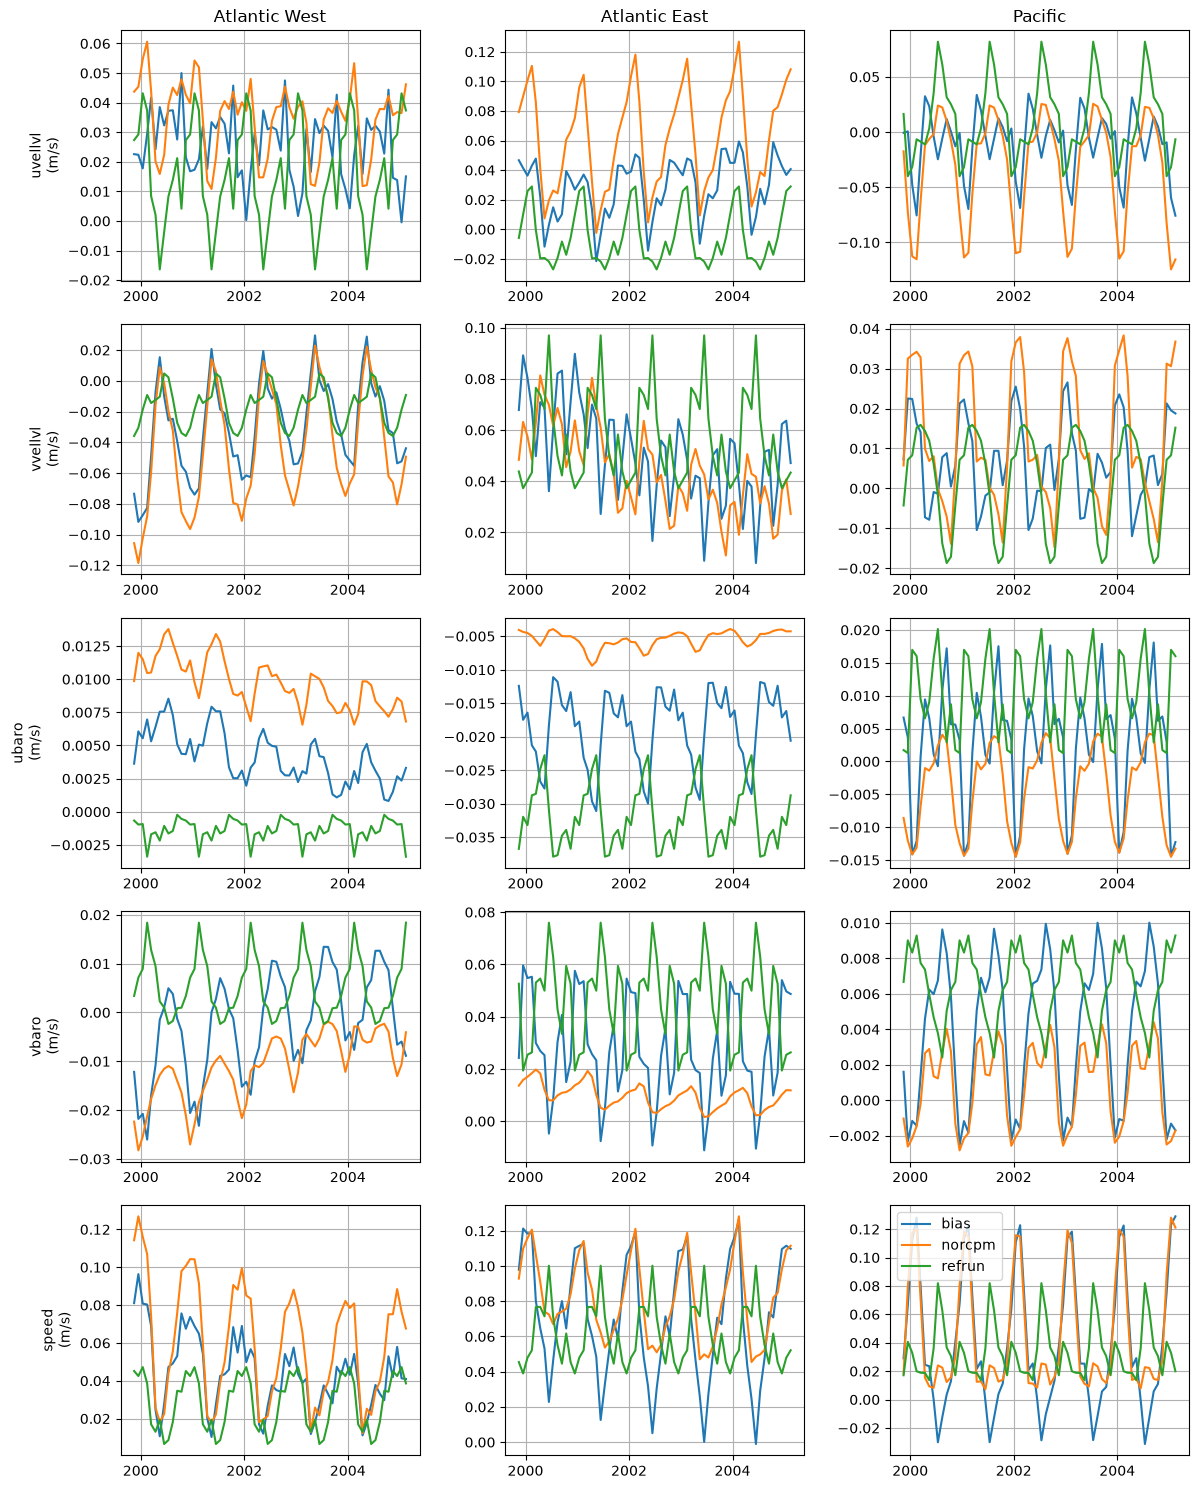

In [19]:
nrows = len(varlist)       # variables
ncols = len(point_idx)     # locations

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(4*ncols, 3*nrows),
    squeeze=False
)

for col, (name, (y, x)) in enumerate(point_idx.items()):
    for row, var in enumerate(varlist):

        ax = axes[row, col]

        if var == "ubaro" or var == "vbaro":
            temp = ds_bias[var].isel(y=y, x=x)
            temp2 = ds_norcpm[var].isel(y=y, x=x)
            temp3 = ds_refrun_interp[var].isel(y=y, x=x)
        else:
            temp = ds_bias[var].isel(y=y, x=x, depth=0)
            temp2 = ds_norcpm[var].isel(y=y, x=x, depth=0)
            temp3 = ds_refrun_interp[var].isel(y=y, x=x, depth=0)

        temp = temp + temp2.mean()/2 + temp3.mean()/2 - temp.mean()

        temp.plot(ax=ax, label="bias")
        temp2.plot(ax=ax, label="norcpm")
        temp3.plot(ax=ax, label="refrun")

        ax.grid(True)

        # Column titles = locations
        if row == 0:
            ax.set_title(name)
        else:
            ax.set_title("")

        # Row labels = variables
        if col == 0:
            ax.set_ylabel(f"{var}\n(m/s)")
        else:
            ax.set_ylabel("")

        ax.set_xlabel("")

plt.tight_layout()
plt.legend()
plt.show()

In [20]:
for var in varlist:
    print(var)
    temp = ds_bias[var]
    #temp.to_netcdf(f"NorCPM_bias/bias_NorCPM_REFRUN_64M_{var}.nc")

uvellvl
vvellvl
ubaro
vbaro
speed
